# Benchmark and direct singular


## Setup

In [1]:
from __future__ import annotations

import copy
import math
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from scipy.sparse import diags, eye
from scipy.sparse.linalg import spsolve
from torch import Tensor, nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float32
SEED = 123

T = 1.0
STEPS = 40
WIDTH = 64
DEPTH = 3
ITERATIONS = 15_000
BATCH_SIZE = 1_024
VALIDATION_SIZE = 8_192
VALIDATE_EVERY = 200
LEARNING_RATE = 1.0e-3

RESULTS_DIR = Path("benchmark_direct_results")
FIGURES = RESULTS_DIR / "figures"
TABLES = RESULTS_DIR / "tables"
MODELS = RESULTS_DIR / "models"

for folder in (RESULTS_DIR, FIGURES, TABLES, MODELS):
    folder.mkdir(parents=True, exist_ok=True)

print("device", DEVICE)

device cuda


## Shared functions

In [2]:
def seed_all(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_generator(seed: int) -> torch.Generator:
    try:
        generator = torch.Generator(device=DEVICE)
    except TypeError:
        generator = torch.Generator()
    generator.manual_seed(seed)
    return generator


def normal_cdf(value: Tensor) -> Tensor:
    return 0.5 * (1.0 + torch.erf(value / math.sqrt(2.0)))


def tensor_to_numpy(value: Tensor) -> np.ndarray:
    return value.detach().cpu().numpy()


def time_column(step: int, batch_size: int) -> Tensor:
    value = float(step) * T / STEPS
    return torch.full((batch_size, 1), value, device=DEVICE, dtype=DTYPE)


def antithetic_batch(
    batch_size: int,
    x_low: float,
    x_high: float,
    rng: torch.Generator,
) -> tuple[Tensor, Tensor]:
    if batch_size % 2:
        raise ValueError("batch_size must be even")
    half = batch_size // 2
    x = x_low + (x_high - x_low) * torch.rand(
        half, 2, generator=rng, device=DEVICE, dtype=DTYPE
    )
    normal = torch.randn(
        half, STEPS, 2, generator=rng, device=DEVICE, dtype=DTYPE
    )
    x = torch.cat((x, x), dim=0)
    normal = torch.cat((normal, -normal), dim=0)
    return x, math.sqrt(T / STEPS) * normal


class MLP(nn.Module):
    def __init__(
        self,
        input_dim: int,
        output_dim: int,
        center: tuple[float, ...],
        scale: tuple[float, ...],
    ) -> None:
        super().__init__()
        self.register_buffer(
            "center", torch.tensor(center, dtype=DTYPE).reshape(1, -1)
        )
        self.register_buffer(
            "scale", torch.tensor(scale, dtype=DTYPE).reshape(1, -1)
        )

        layers: list[nn.Module] = []
        current = input_dim
        for _ in range(DEPTH):
            layers.extend((nn.Linear(current, WIDTH), nn.Softplus()))
            current = WIDTH
        layers.append(nn.Linear(current, output_dim))
        self.net = nn.Sequential(*layers)

        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.xavier_uniform_(layer.weight)
                nn.init.zeros_(layer.bias)

    def forward(self, x: Tensor) -> Tensor:
        return self.net((x - self.center) / self.scale)


class DirectDeepBSDE(nn.Module):
    def __init__(self, problem: "DirectProblem") -> None:
        super().__init__()
        self.V = MLP(
            problem.value_input,
            problem.y_dim,
            problem.value_center,
            problem.value_scale,
        )
        self.Z = MLP(
            problem.z_input,
            problem.y_dim * problem.brownian_dim,
            problem.z_center,
            problem.z_scale,
        )


class DirectProblem:
    name = "problem"
    y_dim = 1
    brownian_dim = 2

    value_input: int
    z_input: int
    value_center: tuple[float, ...]
    value_scale: tuple[float, ...]
    z_center: tuple[float, ...]
    z_scale: tuple[float, ...]

    def sample(self, batch_size: int, rng: torch.Generator) -> tuple[Tensor, Tensor]:
        raise NotImplementedError

    def initial_state(self, x0: Tensor) -> dict[str, Tensor]:
        return {}

    def value_features(self, x: Tensor, state: dict[str, Tensor]) -> Tensor:
        raise NotImplementedError

    def z_features(
        self,
        step: int,
        x: Tensor,
        state: dict[str, Tensor],
    ) -> Tensor:
        raise NotImplementedError

    def monitor(
        self,
        step: int,
        x: Tensor,
        y: Tensor,
        state: dict[str, Tensor],
    ) -> tuple[Tensor, dict[str, Tensor]]:
        return y, state

    def transform_z(
        self,
        raw_z: Tensor,
        state: dict[str, Tensor],
    ) -> Tensor:
        return raw_z.reshape(-1, self.y_dim, self.brownian_dim)

    def driver(
        self,
        step: int,
        x: Tensor,
        y: Tensor,
        z: Tensor,
        state: dict[str, Tensor],
    ) -> Tensor:
        return torch.zeros_like(y)

    def project_y(self, y: Tensor, state: dict[str, Tensor]) -> Tensor:
        return y

    def forward_step(self, x: Tensor, dw: Tensor) -> Tensor:
        raise NotImplementedError

    def terminal_target(
        self,
        x: Tensor,
        state: dict[str, Tensor],
    ) -> Tensor:
        raise NotImplementedError


def direct_rollout(
    model: DirectDeepBSDE,
    problem: DirectProblem,
    x0: Tensor,
    dw: Tensor,
    *,
    return_history: bool = False,
) -> dict[str, Tensor | dict[str, Tensor]]:
    dt = T / STEPS
    x = x0
    state = problem.initial_state(x0)
    y = model.V(problem.value_features(x0, state))

    y_history: list[Tensor] = []
    state_history: list[Tensor] = []

    for k in range(STEPS):
        y, state = problem.monitor(k, x, y, state)
        y = problem.project_y(y, state)

        if return_history:
            y_history.append(y)
            if "alive" in state:
                state_history.append(state["alive"])

        raw_z = model.Z(problem.z_features(k, x, state))
        z = problem.transform_z(raw_z, state)

        y = y + problem.driver(k, x, y, z, state) * dt
        y = y + torch.einsum("bij,bj->bi", z, dw[:, k])
        y = problem.project_y(y, state)

        x = problem.forward_step(x, dw[:, k])

    y, state = problem.monitor(STEPS, x, y, state)
    y = problem.project_y(y, state)
    target = problem.terminal_target(x, state)

    if return_history:
        y_history.append(y)
        if "alive" in state:
            state_history.append(state["alive"])

    result: dict[str, Tensor | dict[str, Tensor]] = {
        "x": x,
        "y": y,
        "target": target,
        "state": state,
    }
    if return_history:
        result["y_history"] = torch.stack(y_history, dim=1)
        if state_history:
            result["alive_history"] = torch.stack(state_history, dim=1)

    return result


def direct_terminal_loss(
    model: DirectDeepBSDE,
    problem: DirectProblem,
    x0: Tensor,
    dw: Tensor,
) -> Tensor:
    output = direct_rollout(model, problem, x0, dw)
    return (output["y"] - output["target"]).square().mean()


def fit_problem(
    problem: DirectProblem,
    seed: int,
) -> tuple[DirectDeepBSDE, pd.DataFrame]:
    seed_all(seed)
    model = DirectDeepBSDE(problem).to(DEVICE)

    train_rng = make_generator(seed)
    validation_rng = make_generator(seed + 1)
    validation = problem.sample(VALIDATION_SIZE, validation_rng)

    optimiser = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    best_loss = math.inf
    best_state = copy.deepcopy(model.state_dict())
    history: list[tuple[int, float, float]] = []

    for iteration in range(ITERATIONS + 1):
        train_loss = math.nan

        if iteration:
            model.train()
            x0, dw = problem.sample(BATCH_SIZE, train_rng)

            optimiser.zero_grad(set_to_none=True)
            loss = direct_terminal_loss(model, problem, x0, dw)

            if not torch.isfinite(loss):
                raise FloatingPointError("non-finite training loss")

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 10.0)
            optimiser.step()
            train_loss = float(loss.detach().cpu())

        validation_loss = math.nan
        if iteration % VALIDATE_EVERY == 0 or iteration == ITERATIONS:
            model.eval()
            with torch.no_grad():
                validation_loss = float(
                    direct_terminal_loss(model, problem, *validation).cpu()
                )
            if validation_loss < best_loss:
                best_loss = validation_loss
                best_state = copy.deepcopy(model.state_dict())

        history.append((iteration, train_loss, validation_loss))

        if iteration and iteration % 1000 == 0:
            print(problem.name, iteration, train_loss, validation_loss)

    model.load_state_dict(best_state)
    model.eval()

    history_df = pd.DataFrame(
        history,
        columns=("iteration", "train", "validation"),
    )
    return model, history_df


def plot_loss(history: pd.DataFrame, title: str) -> plt.Figure:
    fig, ax = plt.subplots(figsize=(6.4, 3.8))
    train = history.dropna(subset=["train"])
    validation = history.dropna(subset=["validation"])

    ax.semilogy(train["iteration"], train["train"], label="training")
    ax.semilogy(
        validation["iteration"],
        validation["validation"],
        marker="o",
        markersize=2.5,
        label="validation",
    )
    ax.set_xlabel("iteration")
    ax.set_ylabel("terminal MSE")
    ax.set_title(title)
    ax.legend()
    fig.tight_layout()
    return fig


def save_figure(fig: plt.Figure, stem: str) -> None:
    fig.savefig(FIGURES / f"{stem}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURES / f"{stem}.pdf", bbox_inches="tight")
    plt.show()
    plt.close(fig)



seed_all(SEED)

## Black Scholes Barenblatt

Black Scholes Barenblatt 1000 0.0023600971326231956 0.0023911711759865284
Black Scholes Barenblatt 2000 0.0008621342713013291 0.0018025180324912071
Black Scholes Barenblatt 3000 0.00018047101912088692 0.0002578485291451216
Black Scholes Barenblatt 4000 0.00016674376092851162 0.00016507595137227327
Black Scholes Barenblatt 5000 9.222301741829142e-05 0.00011230968084419146
Black Scholes Barenblatt 6000 0.00010587932774797082 0.00016203027917072177
Black Scholes Barenblatt 7000 0.0005779022467322648 0.0007187430746853352
Black Scholes Barenblatt 8000 0.00012283932301215827 0.0001374261628370732
Black Scholes Barenblatt 9000 0.00014879083028063178 0.00014100229600444436
Black Scholes Barenblatt 10000 0.00012496687122620642 0.00012676813639700413
Black Scholes Barenblatt 11000 0.00011582011939026415 8.766756218392402e-05
Black Scholes Barenblatt 12000 0.00017749772814568132 0.0001132906909333542
Black Scholes Barenblatt 13000 0.00012602086644619703 0.00017418156494386494
Black Scholes Baren

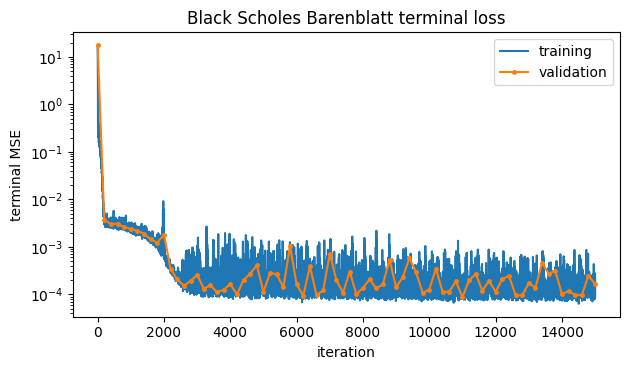

In [3]:
class BlackScholesBarenblatt(DirectProblem):
    name = "Black Scholes Barenblatt"
    y_dim = 1
    brownian_dim = 2

    value_input = 2
    z_input = 3

    value_center = (1.0, 1.0)
    value_scale = (0.5, 0.5)
    z_center = (0.5, 1.0, 1.0)
    z_scale = (0.5, 0.75, 0.75)

    r = 0.05
    nu = 0.20

    def sample(
        self,
        batch_size: int,
        rng: torch.Generator,
    ) -> tuple[Tensor, Tensor]:
        return antithetic_batch(batch_size, 0.5, 1.5, rng)

    def value_features(self, x: Tensor, state: dict[str, Tensor]) -> Tensor:
        return x

    def z_features(
        self,
        step: int,
        x: Tensor,
        state: dict[str, Tensor],
    ) -> Tensor:
        return torch.cat((time_column(step, x.shape[0]), x), dim=1)

    def driver(
        self,
        step: int,
        x: Tensor,
        y: Tensor,
        z: Tensor,
        state: dict[str, Tensor],
    ) -> Tensor:
        return self.r * (y - z.sum(dim=2) / self.nu)

    def forward_step(self, x: Tensor, dw: Tensor) -> Tensor:
        return x + self.nu * x * dw

    def terminal_target(
        self,
        x: Tensor,
        state: dict[str, Tensor],
    ) -> Tensor:
        return 0.5 * x.square().sum(dim=1, keepdim=True)


bsb_problem = BlackScholesBarenblatt()
bsb_model, bsb_history = fit_problem(bsb_problem, SEED + 100)

fig = plot_loss(bsb_history, "Black Scholes Barenblatt terminal loss")
save_figure(fig, "BSB_Loss")

bsb_history.to_csv(TABLES / "BSB_training_history.csv", index=False)

torch.save(bsb_model.state_dict(), MODELS / "BSB_model.pt")

### Benchmark validation

,Diagnostic,Value
0,Neural field MAE vs finite difference,0.001799
1,Neural field MAE vs analytical,0.001803
2,Finite-difference MAE vs analytical,0.000007
3,Neural Z RMSE vs analytical,0.001773


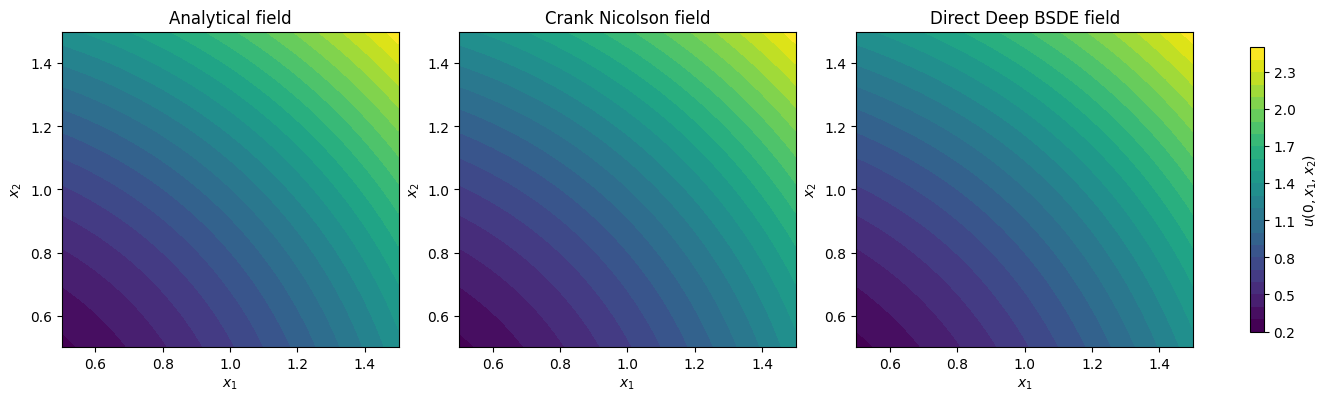

In [4]:
def exact_bsb(t: float, x: Tensor) -> Tensor:
    factor = math.exp(
        (bsb_problem.r + bsb_problem.nu**2) * (T - t)
    )
    return 0.5 * factor * x.square().sum(dim=1, keepdim=True)


def exact_bsb_z(t: float, x: Tensor) -> Tensor:
    factor = bsb_problem.nu * math.exp(
        (bsb_problem.r + bsb_problem.nu**2) * (T - t)
    )
    return factor * x.square()


def solve_bsb_pde(
    nx: int = 401,
    nt: int = 400,
) -> tuple[np.ndarray, np.ndarray]:
    x_min, x_max = 0.1, 2.5
    x = np.linspace(x_min, x_max, nx)
    tau = np.linspace(0.0, T, nt + 1)

    dx = x[1] - x[0]
    dt = tau[1] - tau[0]
    interior = x[1:-1]

    r = bsb_problem.r
    nu = bsb_problem.nu

    lower = 0.5 * nu**2 * interior**2 / dx**2 - 0.5 * r * interior / dx
    main = -nu**2 * interior**2 / dx**2 - r
    upper = 0.5 * nu**2 * interior**2 / dx**2 + 0.5 * r * interior / dx

    operator = diags(
        (lower[1:], main, upper[:-1]),
        (-1, 0, 1),
        format="csc",
    )
    identity = eye(nx - 2, format="csc")
    left = identity - 0.5 * dt * operator
    right = identity + 0.5 * dt * operator

    value = 0.5 * x**2
    growth = r + nu**2

    for n in range(nt):
        old_tau = tau[n]
        new_tau = tau[n + 1]

        old_boundary = 0.5 * np.exp(growth * old_tau) * np.array(
            [x_min**2, x_max**2]
        )
        new_boundary = 0.5 * np.exp(growth * new_tau) * np.array(
            [x_min**2, x_max**2]
        )

        forcing = np.zeros(nx - 2)
        forcing[0] = 0.5 * dt * lower[0] * (
            old_boundary[0] + new_boundary[0]
        )
        forcing[-1] = 0.5 * dt * upper[-1] * (
            old_boundary[1] + new_boundary[1]
        )

        interior_value = spsolve(
            left,
            right @ value[1:-1] + forcing,
        )
        value = np.r_[
            new_boundary[0],
            interior_value,
            new_boundary[1],
        ]

    return x, value


PDE_X, PDE_W = solve_bsb_pde()


def pde_bsb(points: np.ndarray) -> np.ndarray:
    return (
        np.interp(points[:, 0], PDE_X, PDE_W)
        + np.interp(points[:, 1], PDE_X, PDE_W)
    )


@torch.no_grad()
def evaluate_bsb() -> tuple[pd.DataFrame, dict[str, np.ndarray]]:
    grid = torch.linspace(
        0.5,
        1.5,
        61,
        device=DEVICE,
        dtype=DTYPE,
    )
    x1, x2 = torch.meshgrid(grid, grid, indexing="ij")
    points = torch.stack((x1.ravel(), x2.ravel()), dim=1)

    neural = bsb_model.V(points)[:, 0]
    exact = exact_bsb(0.0, points)[:, 0]
    pde = torch.tensor(
        pde_bsb(points.detach().cpu().numpy()),
        device=DEVICE,
        dtype=DTYPE,
    )

    raw_z = bsb_model.Z(
        bsb_problem.z_features(0, points, {})
    )
    z = raw_z.reshape(-1, 2)

    metrics = pd.DataFrame(
        {
            "Diagnostic": [
                "Neural field MAE vs finite difference",
                "Neural field MAE vs analytical",
                "Finite-difference MAE vs analytical",
                "Neural Z RMSE vs analytical",
            ],
            "Value": [
                (neural - pde).abs().mean().item(),
                (neural - exact).abs().mean().item(),
                (pde - exact).abs().mean().item(),
                (z - exact_bsb_z(0.0, points)).square().mean().sqrt().item(),
            ],
        }
    )

    fields = {
        "x1": tensor_to_numpy(x1),
        "x2": tensor_to_numpy(x2),
        "exact": tensor_to_numpy(exact.reshape(61, 61)),
        "pde": tensor_to_numpy(pde.reshape(61, 61)),
        "neural": tensor_to_numpy(neural.reshape(61, 61)),
        "error": tensor_to_numpy((neural - exact).abs().reshape(61, 61)),
    }
    return metrics, fields



bsb_metrics, bsb_fields = evaluate_bsb()
display(bsb_metrics.round(6))
bsb_metrics.to_csv(TABLES / "BSB_metrics.csv", index=False)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(13.2, 3.9),
    constrained_layout=True,
)

field_keys = ("exact", "pde", "neural")
field_titles = (
    "Analytical field",
    "Crank Nicolson field",
    "Direct Deep BSDE field",
)

all_values = np.concatenate(
    [bsb_fields[key].ravel() for key in field_keys]
)
vmin = float(all_values.min())
vmax = float(all_values.max())

image = None
for ax, key, title in zip(axes, field_keys, field_titles):
    image = ax.contourf(
        bsb_fields["x1"],
        bsb_fields["x2"],
        bsb_fields[key],
        25,
        vmin=vmin,
        vmax=vmax,
    )
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(title)

fig.colorbar(
    image,
    ax=axes,
    shrink=0.9,
    label="$u(0,x_1,x_2)$",
)
save_figure(fig, "BSB_Field")

In [5]:
@torch.no_grad()
def benchmark_precision_check():
    grid = torch.linspace(
        0.5, 1.5, 61,
        device=DEVICE, dtype=DTYPE,
    )

    x1, x2 = torch.meshgrid(grid, grid, indexing="ij")
    points = torch.stack(
        (x1.reshape(-1), x2.reshape(-1)), dim=1
    )

    neural = bsb_model.V(points)[:, 0]
    exact = exact_bsb(0.0, points)[:, 0]

    pde = torch.tensor(
        pde_bsb(points.detach().cpu().numpy()),
        device=DEVICE,
        dtype=DTYPE,
    )

    neural_fd = (neural - pde).abs().mean().item()
    neural_exact = (neural - exact).abs().mean().item()
    fd_exact = (pde - exact).abs().mean().item()

    return pd.DataFrame({
        "Quantity": [
            "Neural vs finite difference MAE",
            "Neural vs analytical MAE",
            "Finite difference vs analytical MAE",
            "Difference between first two MAEs",
        ],
        "Value": [
            neural_fd,
            neural_exact,
            fd_exact,
            abs(neural_fd - neural_exact),
        ],
    })


precision_table = benchmark_precision_check()

display(
    precision_table.style
    .format({"Value": "{:.10f}"})
    .hide(axis="index")
)

precision_table.to_csv(
    TABLES / "BSB_precision.csv",
    index=False,
)

Quantity,Value
Neural vs finite difference MAE,0.0017986043
Neural vs analytical MAE,0.0018026368
Finite difference vs analytical MAE,0.0000065843
Difference between first two MAEs,0.0000040325


## Direct singular

Training starts at \(t=0\) with initial states sampled on \([1,4]^2\). The direct experiment uses the same 40 interval Deep BSDE implementation as the benchmark. The hit decision is detached from the gradient. The experiment learns the aggregate \(Y\) and \(Z\).

direct singular 1000 0.03732994943857193 0.03864654153585434
direct singular 2000 0.025511356070637703 0.024710725992918015
direct singular 3000 0.019129198044538498 0.020467251539230347
direct singular 4000 0.01973685808479786 0.01813904196023941
direct singular 5000 0.017441483214497566 0.015722643584012985
direct singular 6000 0.015282897278666496 0.015229674987494946
direct singular 7000 0.014194248244166374 0.014468097127974033
direct singular 8000 0.012710985727608204 0.014295767992734909
direct singular 9000 0.011274270713329315 0.013522030785679817
direct singular 10000 0.012035184539854527 0.013242490589618683
direct singular 11000 0.01613699644804001 0.012981750071048737
direct singular 12000 0.012726420536637306 0.012701998464763165
direct singular 13000 0.013049222528934479 0.01240859366953373
direct singular 14000 0.012651477009057999 0.011963395401835442
direct singular 15000 0.012230200693011284 0.012272986583411694


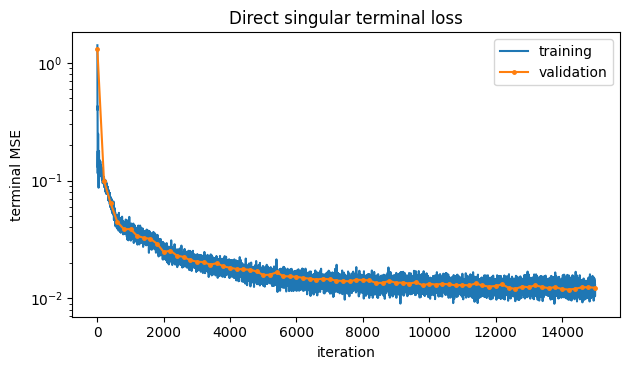

In [6]:
class DirectSingular(DirectProblem):
    name = "direct singular"
    y_dim = 1
    brownian_dim = 2

    value_input = 4
    z_input = 5

    value_center = (2.5, 2.5, 0.5, 0.5)
    value_scale = (1.5, 1.5, 0.5, 0.5)
    z_center = (0.5, 2.5, 2.5, 0.5, 0.5)
    z_scale = (0.5, 1.5, 1.5, 0.5, 0.5)

    sigma = 1.0
    alpha = 1.0
    dead_position = 2.5

    def sample(
        self,
        batch_size: int,
        rng: torch.Generator,
    ) -> tuple[Tensor, Tensor]:
        return antithetic_batch(batch_size, 1.0, 4.0, rng)

    def initial_state(self, x0: Tensor) -> dict[str, Tensor]:
        alive = torch.ones_like(x0, dtype=torch.bool)
        killed = torch.zeros_like(x0, dtype=torch.bool)
        return {
            "alive": alive,
            "killed": killed,
        }

    def value_features(
        self,
        x: Tensor,
        state: dict[str, Tensor],
    ) -> Tensor:
        return torch.cat(
            (x, state["alive"].to(DTYPE)),
            dim=1,
        )

    def monitor(
        self,
        step: int,
        x: Tensor,
        y: Tensor,
        state: dict[str, Tensor],
    ) -> tuple[Tensor, dict[str, Tensor]]:
        alive = state["alive"]
        killed = state["killed"]

        # Hitting rule.
        with torch.no_grad():
            boundary = self.alpha * y.detach()
            new_hit = alive & (x <= boundary)
            killed = killed | new_hit
            alive = alive & (~new_hit)

        return y, {
            "alive": alive,
            "killed": killed,
        }

    def z_features(
        self,
        step: int,
        x: Tensor,
        state: dict[str, Tensor],
    ) -> Tensor:
        alive = state["alive"]

        # Use a fixed value for a dead coordinate.
        network_x = torch.where(
            alive,
            x,
            torch.full_like(x, self.dead_position),
        )

        return torch.cat(
            (
                time_column(step, x.shape[0]),
                network_x,
                alive.to(DTYPE),
            ),
            dim=1,
        )

    def transform_z(
        self,
        raw_z: Tensor,
        state: dict[str, Tensor],
    ) -> Tensor:
        z = raw_z.reshape(-1, 1, 2)

        # Dead coordinates have zero Z loading.
        return z * state["alive"].unsqueeze(1).to(DTYPE)

    def forward_step(
        self,
        x: Tensor,
        dw: Tensor,
    ) -> Tensor:
        return x + self.sigma * dw

    def terminal_target(
        self,
        x: Tensor,
        state: dict[str, Tensor],
    ) -> Tensor:
        # Terminal default count.
        return (
            state["killed"]
            .to(DTYPE)
            .sum(dim=1, keepdim=True)
        )


singular_problem = DirectSingular()
singular_model, singular_history = fit_problem(
    singular_problem,
    SEED + 300,
)

fig = plot_loss(
    singular_history,
    "Direct singular terminal loss",
)
save_figure(fig, "Direct_Singular_Loss")

singular_history.to_csv(
    TABLES / "Direct_Singular_training_history.csv",
    index=False,
)

torch.save(
    singular_model.state_dict(),
    MODELS / "Direct_Singular_model.pt",
)

### Direct singular diagnostics

In [7]:
@torch.no_grad()
def evaluate_direct_singular() -> tuple[pd.DataFrame, dict[str, np.ndarray]]:
    rng = make_generator(SEED + 400)
    x0, dw = singular_problem.sample(
        8_192,
        rng,
    )

    output = direct_rollout(
        singular_model,
        singular_problem,
        x0,
        dw,
        return_history=True,
    )

    y = output["y"]
    target = output["target"]
    y_history = output["y_history"]
    state = output["state"]

    residual = y - target

    range_violation = (
        ((y_history < 0.0) | (y_history > 2.0))
        .float()
        .mean()
        .item()
    )

    killed_count = state["killed"].sum(dim=1)
    no_default_rate = (killed_count == 0).float().mean().item()
    one_default_rate = (killed_count == 1).float().mean().item()
    two_default_rate = (killed_count == 2).float().mean().item()

    grid = torch.linspace(
        1.0,
        4.0,
        61,
        device=DEVICE,
        dtype=DTYPE,
    )
    x1, x2 = torch.meshgrid(grid, grid, indexing="ij")
    points = torch.stack(
        (x1.ravel(), x2.ravel()),
        dim=1,
    )

    initial_state = singular_problem.initial_state(points)
    aggregate = singular_model.V(
        singular_problem.value_features(
            points,
            initial_state,
        )
    )[:, 0]

    margin = (
        points.min(dim=1).values
        - singular_problem.alpha * aggregate
    )

    metrics = pd.DataFrame(
        {
            "Diagnostic": [
                "Terminal RMSE",
                "Mean terminal default count",
                "Recorded aggregate range violation rate",
                "Minimum time zero aggregate field",
                "Maximum time zero aggregate field",
                "No default rate",
                "One default rate",
                "Two default rate",
            ],
            "Value": [
                residual.square().mean().sqrt().item(),
                target.mean().item(),
                range_violation,
                aggregate.min().item(),
                aggregate.max().item(),
                no_default_rate,
                one_default_rate,
                two_default_rate,
            ],
        }
    )

    fields = {
        "x1": tensor_to_numpy(x1),
        "x2": tensor_to_numpy(x2),
        "aggregate": tensor_to_numpy(
            aggregate.reshape(61, 61)
        ),
        "margin": tensor_to_numpy(
            margin.reshape(61, 61)
        ),
    }

    return metrics, fields


singular_metrics, singular_fields = evaluate_direct_singular()
display(singular_metrics.round(6))

singular_metrics.to_csv(
    TABLES / "Direct_Singular_metrics.csv",
    index=False,
)

,Diagnostic,Value
0,Terminal RMSE,0.106965
1,Mean terminal default count,0.679810
2,Recorded aggregate range violation rate,0.240267
3,Minimum time zero aggregate field,0.001353
4,Maximum time zero aggregate field,2.072995
5,No default rate,0.546875
6,One default rate,0.226440
7,Two default rate,0.226685


## N2 exact geometry reference

The reference uses the analytical singleton boundary and 400 endpoint monitoring intervals. It is a discretely monitored exact geometry reference rather than a continuous time benchmark.

reference t=0.00
reference t=0.20
reference t=0.40
reference t=0.60
reference t=0.75
reference t=0.90
reference t=0.95
reference t=1.00


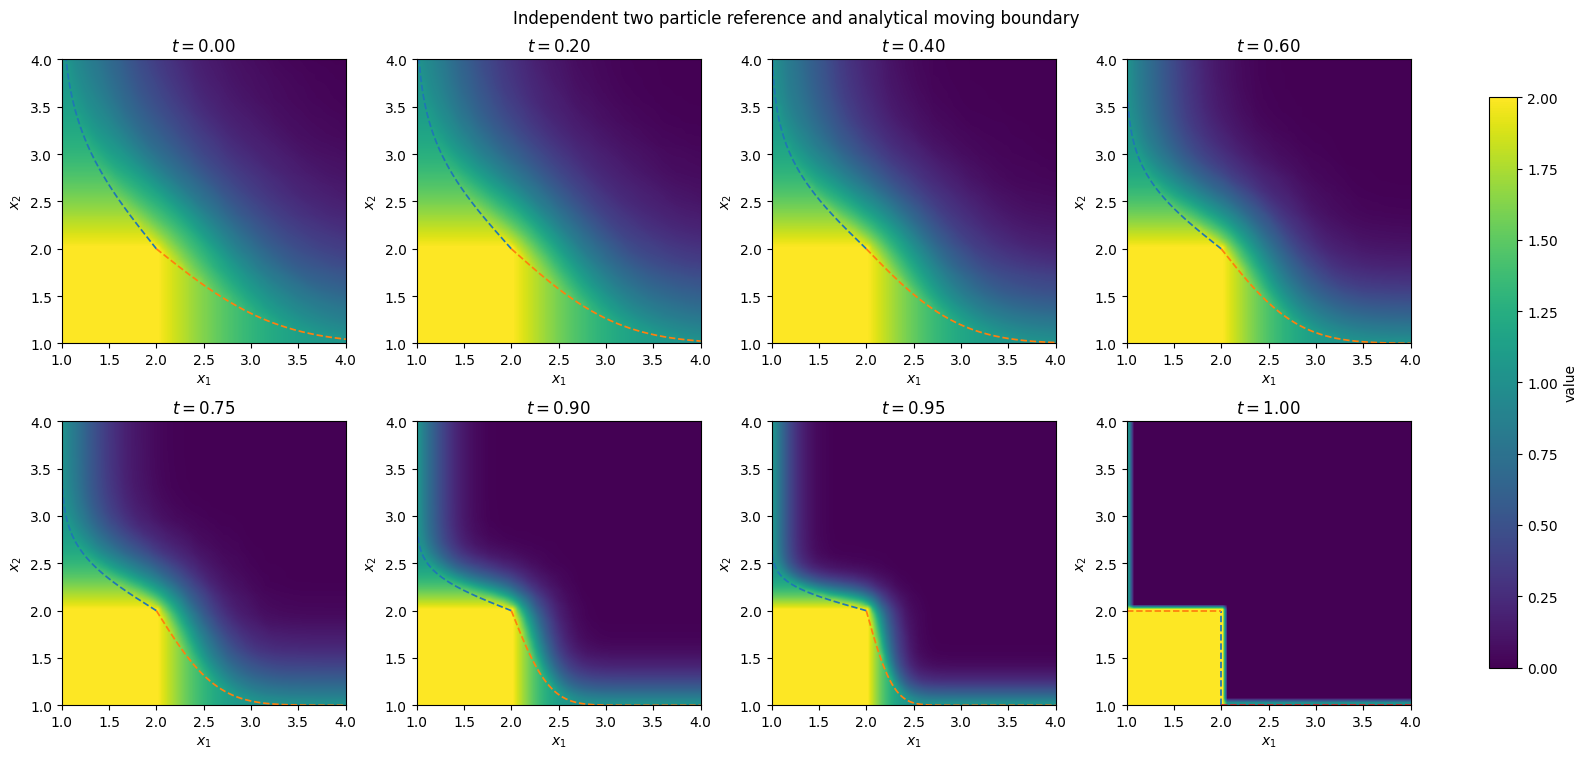

,Time,Mean Monte Carlo SE,Maximum Monte Carlo SE
0,0.00,0.009544,0.013396
1,0.20,0.008908,0.013642
2,0.40,0.008089,0.014167
3,0.60,0.006883,0.014425
4,0.75,0.005654,0.015025
5,0.90,0.003772,0.015676
6,0.95,0.002866,0.015938
7,1.00,0.000000,0.000000


In [8]:
SIGMA = singular_problem.sigma
ALPHA = singular_problem.alpha
X_MIN = 1.0
X_MAX = 4.0

GEOMETRY_TIMES = (0.00, 0.20, 0.40, 0.60, 0.75, 0.90, 0.95, 1.00)
REFERENCE_GRID_SIZE = 61
REFERENCE_PATHS = 2_048
REFERENCE_STEPS = 400
REFERENCE_POINT_BATCH = 32


def exact_singleton_value(t: float | Tensor, x: Tensor) -> Tensor:
    t_tensor = torch.as_tensor(t, device=x.device, dtype=x.dtype)
    t_tensor, x_tensor = torch.broadcast_tensors(t_tensor, x)

    remaining = T - t_tensor
    terminal = torch.where(
        x_tensor <= 2.0 * ALPHA,
        torch.full_like(x_tensor, 2.0),
        torch.full_like(x_tensor, 1.0),
    )

    safe_remaining = remaining.clamp_min(torch.finfo(x.dtype).eps)
    argument = torch.minimum(
        (2.0 * ALPHA - x_tensor)
        / (SIGMA * torch.sqrt(safe_remaining)),
        torch.zeros_like(x_tensor),
    )

    preterminal = 1.0 + 2.0 * normal_cdf(argument)
    return torch.where(
        remaining <= 1.0e-12,
        terminal,
        preterminal,
    )


def exact_boundary_value(
    t: float | Tensor,
    survivor: Tensor,
) -> Tensor:
    return ALPHA * exact_singleton_value(t, survivor)


def exact_terminal_continuation_mask(points: Tensor) -> Tensor:
    smaller = points.min(dim=1).values
    larger = points.max(dim=1).values
    return (smaller > ALPHA) & (larger > 2.0 * ALPHA)


def exact_continuation_mask(
    t: float,
    points: Tensor,
) -> Tensor:
    if abs(t - T) <= 1.0e-12:
        return exact_terminal_continuation_mask(points)

    smaller = points.min(dim=1).values
    larger = points.max(dim=1).values
    return smaller > exact_boundary_value(t, larger)


def exact_boundary_curves(
    t: float,
) -> list[tuple[np.ndarray, np.ndarray]]:
    if abs(t - T) <= 1.0e-12:
        low = np.linspace(X_MIN, 2.0 * ALPHA, 500)
        high = np.linspace(2.0 * ALPHA, X_MAX, 500)
        return [
            (np.full_like(low, 2.0 * ALPHA), low),
            (low, np.full_like(low, 2.0 * ALPHA)),
            (np.full_like(high, ALPHA), high),
            (high, np.full_like(high, ALPHA)),
        ]

    survivor = torch.linspace(
        max(X_MIN, 2.0 * ALPHA),
        X_MAX,
        800,
        device=DEVICE,
        dtype=DTYPE,
    )
    boundary = exact_boundary_value(t, survivor)
    feasible = boundary <= survivor + 10.0 * torch.finfo(DTYPE).eps

    survivor = survivor[feasible]
    boundary = boundary[feasible]

    return [
        (tensor_to_numpy(boundary), tensor_to_numpy(survivor)),
        (tensor_to_numpy(survivor), tensor_to_numpy(boundary)),
    ]


def plot_exact_boundary(
    ax: plt.Axes,
    t: float,
    label: str | None = None,
) -> None:
    for index, (x_curve, y_curve) in enumerate(exact_boundary_curves(t)):
        ax.plot(
            x_curve,
            y_curve,
            linestyle="--",
            linewidth=1.25,
            label=label if index == 0 else None,
        )


@torch.no_grad()
def reference_payoff_chunk(
    start_time: float,
    points: Tensor,
    increments: Tensor,
) -> Tensor:
    n_points = points.shape[0]
    n_paths = increments.shape[0]
    n_steps = increments.shape[1]
    dt = (T - start_time) / n_steps

    x = points[:, None, :].expand(n_points, n_paths, 2).clone()
    active = torch.ones(
        n_points,
        n_paths,
        device=DEVICE,
        dtype=torch.bool,
    )
    payoff = torch.zeros(
        n_points,
        n_paths,
        device=DEVICE,
        dtype=DTYPE,
    )

    for k in range(n_steps + 1):
        current_time = start_time + k * dt
        smaller = x.min(dim=2).values
        larger = x.max(dim=2).values
        threshold = exact_boundary_value(current_time, larger)

        new_exit = active & (smaller <= threshold)
        if bool(new_exit.any()):
            payoff[new_exit] = exact_singleton_value(
                current_time,
                larger[new_exit],
            )
            active[new_exit] = False

        if k < n_steps:
            x = x + increments[:, k][None, :, :]

    return payoff


@torch.no_grad()
def compute_reference_surface(start_time: float) -> dict[str, Tensor]:
    axis = torch.linspace(
        X_MIN,
        X_MAX,
        REFERENCE_GRID_SIZE,
        device=DEVICE,
        dtype=DTYPE,
    )
    x1, x2 = torch.meshgrid(axis, axis, indexing="ij")
    points = torch.stack(
        (x1.reshape(-1), x2.reshape(-1)),
        dim=1,
    )

    inside = exact_continuation_mask(start_time, points)
    field = exact_singleton_value(
        start_time,
        points.max(dim=1).values,
    )
    standard_error = torch.zeros_like(field)

    if abs(start_time - T) <= 1.0e-12:
        field[inside] = 0.0
        return {
            "axis": axis.cpu(),
            "inside": inside.cpu(),
            "field": field.cpu(),
            "standard_error": standard_error.cpu(),
        }

    inside_points = points[inside]
    half_paths = REFERENCE_PATHS // 2

    rng = make_generator(
        SEED + 10_000 + int(1_000 * start_time)
    )
    half_normal = torch.randn(
        half_paths,
        REFERENCE_STEPS,
        2,
        generator=rng,
        device=DEVICE,
        dtype=DTYPE,
    )
    normal = torch.cat((half_normal, -half_normal), dim=0)

    dt = (T - start_time) / REFERENCE_STEPS
    increments = SIGMA * math.sqrt(dt) * normal

    estimates: list[Tensor] = []
    errors: list[Tensor] = []

    for start in range(
        0,
        inside_points.shape[0],
        REFERENCE_POINT_BATCH,
    ):
        chunk = inside_points[start : start + REFERENCE_POINT_BATCH]
        samples = reference_payoff_chunk(
            start_time,
            chunk,
            increments,
        )

        pair_means = 0.5 * (
            samples[:, :half_paths]
            + samples[:, half_paths:]
        )

        estimates.append(pair_means.mean(dim=1))
        errors.append(
            pair_means.std(dim=1, unbiased=True)
            / math.sqrt(half_paths)
        )

    if estimates:
        field[inside] = torch.cat(estimates)
        standard_error[inside] = torch.cat(errors)

    return {
        "axis": axis.cpu(),
        "inside": inside.cpu(),
        "field": field.cpu(),
        "standard_error": standard_error.cpu(),
    }


reference_surfaces: dict[float, dict[str, Tensor]] = {}

for t_value in GEOMETRY_TIMES:
    print(f"reference t={t_value:.2f}")
    reference_surfaces[t_value] = compute_reference_surface(t_value)


fig, axes = plt.subplots(
    2,
    4,
    figsize=(15.8, 7.5),
    constrained_layout=True,
)

image = None
for ax, t_value in zip(axes.flat, GEOMETRY_TIMES):
    reference = reference_surfaces[t_value]
    axis = reference["axis"].numpy()
    field = reference["field"].numpy().reshape(
        REFERENCE_GRID_SIZE,
        REFERENCE_GRID_SIZE,
    )

    image = ax.imshow(
        field.T,
        origin="lower",
        extent=(axis[0], axis[-1], axis[0], axis[-1]),
        aspect="equal",
        interpolation="bilinear",
        vmin=0.0,
        vmax=2.0,
    )
    plot_exact_boundary(ax, t_value)
    ax.set_xlabel("$x_1$")
    ax.set_ylabel("$x_2$")
    ax.set_title(f"$t={t_value:.2f}$")

fig.colorbar(image, ax=axes, shrink=0.86, label="value")
fig.suptitle("Independent two particle reference and analytical moving boundary")
save_figure(fig, "reference_field_eight_times")


reference_uncertainty = []
for t_value in GEOMETRY_TIMES:
    reference = reference_surfaces[t_value]
    inside_se = reference["standard_error"][reference["inside"]]
    reference_uncertainty.append(
        {
            "Time": t_value,
            "Mean Monte Carlo SE": (
                float(inside_se.mean()) if inside_se.numel() else 0.0
            ),
            "Maximum Monte Carlo SE": (
                float(inside_se.max()) if inside_se.numel() else 0.0
            ),
        }
    )

reference_uncertainty = pd.DataFrame(reference_uncertainty)
display(reference_uncertainty.round(6))
reference_uncertainty.to_csv(
    TABLES / "reference_monte_carlo_uncertainty.csv",
    index=False,
)

## Direct structural checks

At time zero the exact aggregate field equals \(2\) on \([1,2]^2\). The second check uses the candidate field itself. If \(I(x)=\{i:x_i\leq\alpha\widehat v(0,x)\}\), then a consistent aggregate field must satisfy \(\widehat v(0,x)\geq |I(x)|\).

,Diagnostic,Value
0,Plateau MAE,0.0772
1,Plateau maximum error,0.7490
2,Plateau signed mean error,-0.0429
3,Maximum fixed point shortfall,0.1877
4,Mean fixed point shortfall,0.0017
5,Fraction with fixed point shortfall,0.0359
6,Minimum field value,0.0013
7,Maximum field value,2.0735


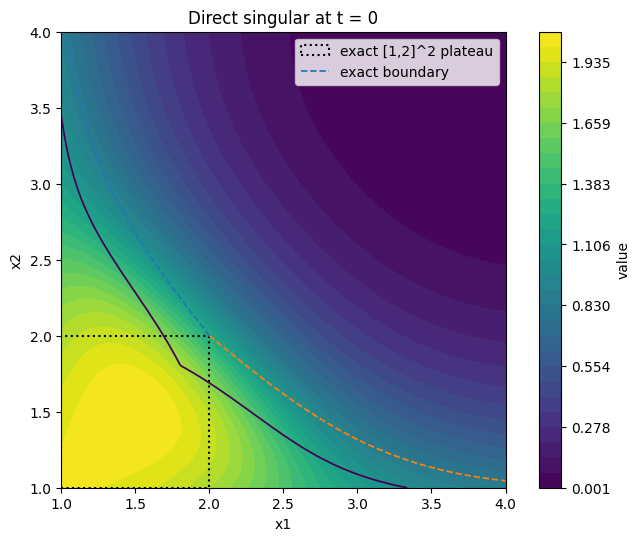

In [9]:
from matplotlib.patches import Rectangle

@torch.no_grad()
def direct_checks(
    plateau_grid: int = 101,
    full_grid: int = 121,
):
    plateau_axis = torch.linspace(
        1.0, 2.0, plateau_grid,
        device=DEVICE, dtype=DTYPE,
    )
    p1, p2 = torch.meshgrid(
        plateau_axis, plateau_axis, indexing="ij"
    )
    plateau_points = torch.stack(
        (p1.reshape(-1), p2.reshape(-1)), dim=1
    )

    state = singular_problem.initial_state(plateau_points)
    plateau_value = singular_model.V(
        singular_problem.value_features(plateau_points, state)
    )[:, 0]
    plateau_error = plateau_value - 2.0

    axis = torch.linspace(
        1.0, 4.0, full_grid,
        device=DEVICE, dtype=DTYPE,
    )
    x1, x2 = torch.meshgrid(axis, axis, indexing="ij")
    points = torch.stack(
        (x1.reshape(-1), x2.reshape(-1)), dim=1
    )

    state = singular_problem.initial_state(points)
    value = singular_model.V(
        singular_problem.value_features(points, state)
    )[:, 0]

    killed_count = (
        points <= singular_problem.alpha * value[:, None]
    ).sum(dim=1).to(DTYPE)

    shortfall = torch.relu(killed_count - value)

    table = pd.DataFrame({
        "Diagnostic": [
            "Plateau MAE",
            "Plateau maximum error",
            "Plateau signed mean error",
            "Maximum fixed point shortfall",
            "Mean fixed point shortfall",
            "Fraction with fixed point shortfall",
            "Minimum field value",
            "Maximum field value",
        ],
        "Value": [
            plateau_error.abs().mean().item(),
            plateau_error.abs().max().item(),
            plateau_error.mean().item(),
            shortfall.max().item(),
            shortfall.mean().item(),
            (shortfall > 1.0e-10).float().mean().item(),
            value.min().item(),
            value.max().item(),
        ],
    })

    fields = {
        "x1": tensor_to_numpy(x1),
        "x2": tensor_to_numpy(x2),
        "value": tensor_to_numpy(value.reshape(full_grid, full_grid)),
        "shortfall": tensor_to_numpy(shortfall.reshape(full_grid, full_grid)),
    }

    return table, fields


direct_check_table, direct_check_fields = direct_checks()
display(direct_check_table.round(4))

direct_check_table.to_csv(
    TABLES / "Direct_Singular_checks.csv",
    index=False,
)

field = direct_check_fields["value"]
vmin = float(np.nanmin(field))
vmax = float(np.nanmax(field))

fig, ax = plt.subplots(figsize=(6.3, 5.3), constrained_layout=True)

surface = ax.contourf(
    direct_check_fields["x1"],
    direct_check_fields["x2"],
    field,
    levels=np.linspace(vmin, vmax, 31),
    vmin=vmin,
    vmax=vmax,
)

fig.colorbar(surface, ax=ax, label="value")

candidate_margin = (
    np.minimum(
        direct_check_fields["x1"],
        direct_check_fields["x2"],
    )
    - singular_problem.alpha * field
)

ax.contour(
    direct_check_fields["x1"],
    direct_check_fields["x2"],
    candidate_margin,
    levels=[0.0],
    linewidths=1.25,
)

ax.add_patch(
    Rectangle(
        (1.0, 1.0),
        1.0,
        1.0,
        fill=False,
        linewidth=1.5,
        linestyle=":",
        label="exact [1,2]^2 plateau",
    )
)

plot_exact_boundary(
    ax,
    0.0,
    label="exact boundary",
)

ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.set_title("Direct singular at t = 0")
ax.legend()

save_figure(fig, "Direct_Singular_Checks")

## Checkpoints

In [10]:
def best_checkpoint(name: str, history: pd.DataFrame) -> dict[str, float | int | str]:
    validation = history.dropna(subset=["validation"])
    row = validation.loc[validation["validation"].idxmin()]

    return {
        "model": name,
        "best iteration": int(row["iteration"]),
        "best validation": float(row["validation"]),
    }


checkpoint_table = pd.DataFrame([
    best_checkpoint("Black Scholes Barenblatt", bsb_history),
    best_checkpoint("Direct singular", singular_history),
])

display(checkpoint_table.round(6))

checkpoint_table.to_csv(
    TABLES / "checkpoint_summary.csv",
    index=False,
)

,model,best iteration,best validation
0,Black Scholes Barenblatt,11000,0.000088
1,Direct singular,14200,0.011854


## Summary

In [11]:
summary = pd.DataFrame({
    "quantity": [
        "BSB neural vs analytical MAE",
        "BSB finite difference vs analytical MAE",
        "Direct terminal RMSE",
        "Direct plateau MAE",
        "Direct plateau maximum error",
        "Direct maximum fixed point shortfall",
        "Direct fixed point violation fraction",
    ],
    "value": [
        float(
            bsb_metrics.loc[
                bsb_metrics["Diagnostic"] == "Neural field MAE vs analytical",
                "Value",
            ].iloc[0]
        ),
        float(
            bsb_metrics.loc[
                bsb_metrics["Diagnostic"] == "Finite-difference MAE vs analytical",
                "Value",
            ].iloc[0]
        ),
        float(
            singular_metrics.loc[
                singular_metrics["Diagnostic"] == "Terminal RMSE",
                "Value",
            ].iloc[0]
        ),
        float(
            direct_check_table.loc[
                direct_check_table["Diagnostic"] == "Plateau MAE",
                "Value",
            ].iloc[0]
        ),
        float(
            direct_check_table.loc[
                direct_check_table["Diagnostic"] == "Plateau maximum error",
                "Value",
            ].iloc[0]
        ),
        float(
            direct_check_table.loc[
                direct_check_table["Diagnostic"] == "Maximum fixed point shortfall",
                "Value",
            ].iloc[0]
        ),
        float(
            direct_check_table.loc[
                direct_check_table["Diagnostic"] == "Fraction with fixed point shortfall",
                "Value",
            ].iloc[0]
        ),
    ],
})

display(summary.round(6))

summary.to_csv(
    TABLES / "summary.csv",
    index=False,
)

print("saved to", RESULTS_DIR.resolve())

,quantity,value
0,BSB neural vs analytical MAE,0.001803
1,BSB finite difference vs analytical MAE,0.000007
2,Direct terminal RMSE,0.106965
3,Direct plateau MAE,0.077227
4,Direct plateau maximum error,0.749030
5,Direct maximum fixed point shortfall,0.187700
6,Direct fixed point violation fraction,0.035927


saved to /content/benchmark_direct_results
